# 14 · From numerical experiments to supported claims

**Time:** 90–120 minutes including project demonstrations. **Preparation:** the completed course. There is no new programming assignment.

Objectives: connect approximation, enclosure, local validation, and global coverage; revisit the opening numerical failures; and explain practical limits without overstating what has been proved.

In [1]:
from fractions import Fraction
import matplotlib.pyplot as plt
from IPython.display import display
from vc.intervals import RationalInterval as Interval
from vc.geometry import orientation
from vc.roots import inspect_root
from vc.optimization import minimize
from vc.systems import matrix_vector

## Four questions to ask of a numerical result

| Result | What it supplies | What still needs justification |
|---|---|---|
| An approximate root or minimizer | A candidate worth investigating | Existence, error, uniqueness, global scope |
| A rigorous function enclosure | A bound on every allowed value | Whether it decides the sign or desired accuracy |
| A local root certificate | Existence/uniqueness in a specified region | Whether roots exist elsewhere |
| A completed global search | A domain-wide claim under its invariant | Input/model assumptions and implementation trust |

Precision can help resolve arithmetic uncertainty. Reformulation can reduce cancellation or dependency. Subdivision can recover information lost by a wide enclosure. None of these repairs automatically supplies a missing coverage argument or removes physical input uncertainty.

## Revisit the opening examples

The cancellation examples taught us to distinguish the mathematical function from its floating-point evaluation. Exact input semantics explained why converting a decimal string and importing a stored float answer different questions. The Patriot-inspired model illustrated accumulated conversion error under explicitly simplified assumptions; its historical engineering context remains in the reference note.

We now have several ways to make a concrete claim stronger: exact rational comparison, directed rounding, a sign enclosure, a derivative bound, or a theorem-backed search. Choose the method that establishes the needed conclusion.

In [2]:
n = 2 ** 27
turn = orientation((0, 0), (n, n - 1), (n + 1, n))
root = inspect_root(lambda X: X.square() - 2, lambda X: 2 * X, Interval(1, 2))
minimum = minimize(lambda X: (X.square() - 1).square(), Interval(-2, 2))
print("Exact-input orientation sign:", turn.sign)
print("One root in [1,2]:", root.status, root.retained)
print("Minimum value:", minimum.minimum, "status:", minimum.status)
print("Minimizer candidate intervals:", [piece.domain for piece in minimum.candidates])

Exact-input orientation sign: 1
One root in [1,2]: certified [11/8, 23/16]
Minimum value: [0, 0] status: gap_met
Minimizer candidate intervals: [[-2, 0], [0, 2]]


## EXPERIMENT · Wrapping without rounding error

A rotation preserves lengths. Yet repeatedly rotating an axis-aligned interval box and replacing the result by another axis-aligned box can make the enclosure grow. This is wrapping: the representation loses relations between coordinates.

Use the exact rational rotation matrix with cosine 3/5 and sine 4/5. Track a square in two ways: repeatedly apply interval matrix arithmetic, and rotate its four exact corners before taking a hull for display. The latter gives the true coordinate ranges because a linear image of a square has extrema at its vertices.

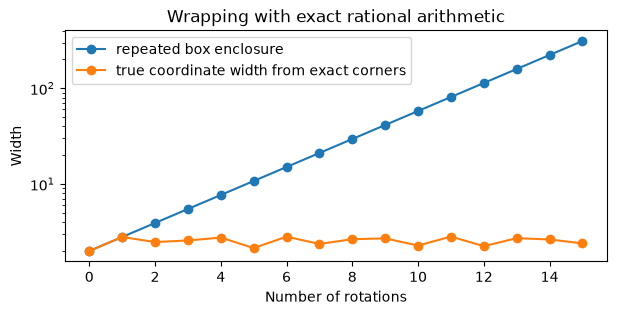

In [3]:
rotation = [[Fraction(3, 5), Fraction(-4, 5)],
            [Fraction(4, 5), Fraction(3, 5)]]
box = [Interval(-1, 1), Interval(-1, 1)]
corners = [(Fraction(x), Fraction(y)) for x in [-1, 1] for y in [-1, 1]]
box_widths, true_widths = [], []
for step in range(16):
    box_widths.append(float(box[0].width()))
    x_values = [point[0] for point in corners]
    true_widths.append(float(max(x_values) - min(x_values)))
    box = matrix_vector(rotation, box)
    new_corners = []
    for x, y in corners:
        new_x = Fraction(3, 5) * x - Fraction(4, 5) * y
        new_y = Fraction(4, 5) * x + Fraction(3, 5) * y
        new_corners.append((new_x, new_y))
    corners = new_corners
fig, ax = plt.subplots(figsize = (7, 3))
ax.semilogy(range(16), box_widths, "o-", label = "repeated box enclosure")
ax.semilogy(range(16), true_widths, "o-", label = "true coordinate width from exact corners")
ax.set(xlabel = "Number of rotations", ylabel = "Width", title = "Wrapping with exact rational arithmetic")
ax.legend()
display(fig)
plt.close(fig)

The widening cannot be blamed on insufficient arithmetic precision: every enclosure update and corner rotation used exact rational arithmetic. Only the plotted widths were converted to floats. A richer representation, better coordinates, or subdivision can help, at a computational cost. The mirror project also loses dependencies between position, direction, and event time as the trajectory grows.

Higher dimension increases the cost of covering domains. Near singularity weakens root and system tests. Nonsmooth branches and ambiguous events require separate reasoning. These limits help determine a project's feasible scope.

## Project demonstrations

Give a short demonstration with the exact claim, one approximate exploration, the validation theorem and decisive bounds, one limitation, and the response to a peer-audit finding. Show the result from a fresh kernel and distinguish approximate plot labels from exact certificate endpoints.

Submit the completed project notebook, its reproducible certificate data where applicable, and the peer audit with the author's response. See [the project rubric](../projects/README.md).

## Claim-classification discussion

Classify each statement and repair it if necessary:

- “Two precisions agree to ten digits, therefore those digits are certified.”
- “The interval determinant contains zero, so the points are collinear.”
- “The system residual is zero, so the surrounding box contains a unique root.”
- “The optimization gap is zero, so the minimizer is localized.”
- “The solver preserved unresolved boxes, so its partial certificate can still be useful.”

A useful answer names the missing hypothesis or computation. For the first four statements, earlier notebooks supply counterexamples; the last statement is valid when the reported partial claims and retained search invariant are stated accurately.

## Beyond this introduction

Taylor models, verified integration and ODE methods, higher-dimensional search, and formal proof assistants are possible next topics. They require additional representations, hypotheses, or software verification; this course has not implemented them. The [advanced-course review](../Doc/existing_course_review.md) records material for later study.

The course's certificates rely on mathematical arguments, exact input descriptions, enclosing arithmetic, and correctly implemented search logic. Testing and peer audit strengthen confidence in those implementations; formal verification would be a separate task.